<a href="https://colab.research.google.com/github/godmsqls/Advanced-Major-Practice/blob/main/AMP_week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 5장 → 처음 내용부터 영상으로 업로드 예정



---


## 6장 : 에지 및 윤곽선 검출

### 01 에지의 의미와 역할 이해

**5단계 순서** !!!!!!!!!!!!!!!! 중요함 시험에 나옴

- 에지 : 영상에서 밝기 값이 급격하게 변하는 **불연속** 지점을 검출한 것

    입력 영상은 주로 그레이스케일
    
    결과 영상은 얇은 선 형태의 에지 픽셀 (연결되지 않을 수 있음)

    ex) 특징점/코너 검출, 영상 정합, 물체 감지의 전처리


- 윤곽선 : 객체(영역)의 경계를 따라 형성되는 닫힌 곡선(연속!!!!!)
    
    입력 영상은 이진 영상(객체 분할 결과)

    결과 영상은 연결된 닫힌 곡선

    ex) 객체의 형태 분석, 면적/둘레 측정, 객체 개수 세기, 형태 인식



OpenCV에서 Canny 사용하기

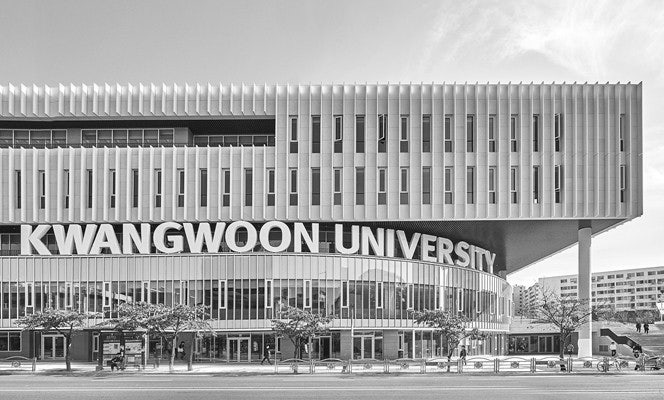

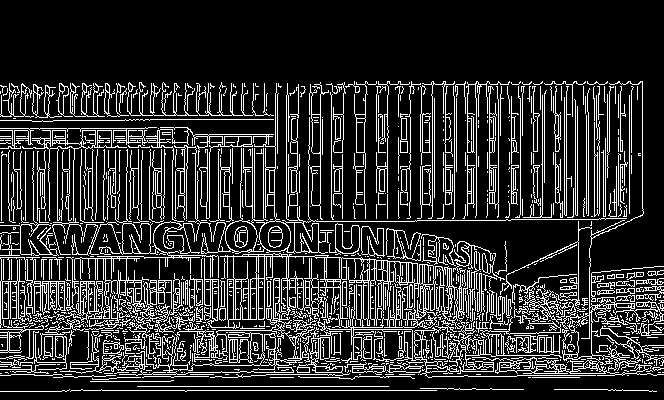

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 영상 불러오기
img = cv2.imread("campus.jpeg")

# 2. 그레이스케일로 변환
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Canny 에지 검출 적용
edges = cv2.Canny(gray, 100, 200)

# 4. 결과 영상 출력 (창 이름 텍스트 없이 이미지 변수만 입력)
cv2_imshow(gray)
cv2_imshow(edges)

원형도 = 4πx둘레/면적 ?

실습 : 도형 개수 세기와 분류

=== 도형 개수 세기 결과 ===
삼각형: 2개
사각형: 3개
원: 4개


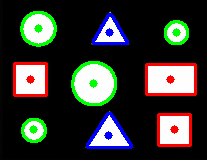

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. 입력 영상 읽기
img = cv2.imread("figure.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. 이진화 및 잡음 제거
# 오츠 알고리즘으로 이진화한 뒤, 형태학적 연산(열림, 닫힘)을 적용해 잡음 제거
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

# 윤곽선 검출
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 개수 저장을 위한 딕셔너리
shape_counts = {'Triangle': 0, 'Square': 0, 'Circle': 0}
result_img = img.copy()

# 3. 각 윤곽선의 도형 분류
for cnt in contours:
    # 미세한 잡음은 면적 필터링으로 무시
    if cv2.contourArea(cnt) < 100:
        continue

    # 윤곽선 근사화(approxPolyDP)를 통해 꼭짓점 개수 파악
    epsilon = 0.04 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    vertices = len(approx)

    # 4. 결과 화면에 개수/중심점 표시를 위한 모멘트(무게중심) 계산
    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = 0, 0

    # 꼭짓점 개수에 따른 분류 및 색상 지정 (OpenCV는 BGR 기준)
    if vertices == 3:
        name = 'Triangle'
        color = (255, 0, 0)  # 파란색
        shape_counts[name] += 1
    elif vertices == 4:
        name = 'Square'
        color = (0, 0, 255)  # 빨간색
        shape_counts[name] += 1
    else:
        # 꼭짓점이 많으면(통상 8개 이상) 원으로 간주
        name = 'Circle'
        color = (0, 255, 0)  # 초록색
        shape_counts[name] += 1

    # 결과 영상에 윤곽선과 중심점 그리기
    cv2.drawContours(result_img, [cnt], 0, color, 2)
    cv2.circle(result_img, (cx, cy), 4, color, -1)

# 4. 콘솔에 개수 결과 출력
print("=== 도형 개수 세기 결과 ===")
print(f"삼각형: {shape_counts['Triangle']}개")
print(f"사각형: {shape_counts['Square']}개")
print(f"원: {shape_counts['Circle']}개")

# 5. 최종 영상 출력
cv2_imshow(result_img)

다양한 윤곽선 시각화 방법

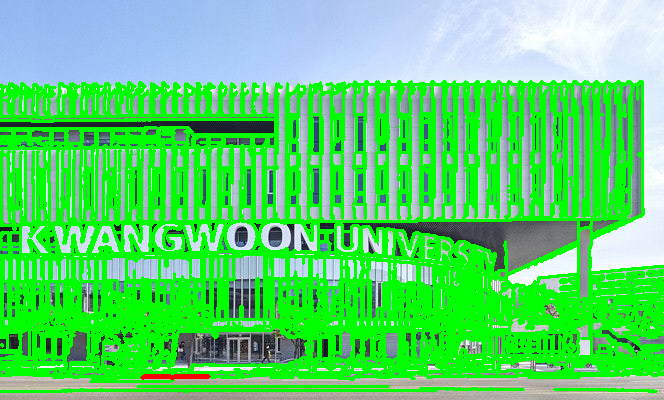

In [8]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("campus.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 0. 윤곽선 찾기(에지 검출, 검출된 에지에서 새로운 윤곽선 찾기)
edges = cv2.Canny(gray, 100, 200)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 1. 모든 윤곽선 그리기 (초록색, 두께 2)
cv2.drawContours(img, contours, -1, (0, 255, 0), 2)

# 2. 특정 윤곽선만 선택해서 그리기 (예: i번째 윤곽선, 빨간색, 두께 3)
i = 11
cv2.drawContours(img, [contours[i]], -1, (0, 0, 255), 3)

# 3. 최종 영상 출력
cv2_imshow(img)

종합 실습 예제 1

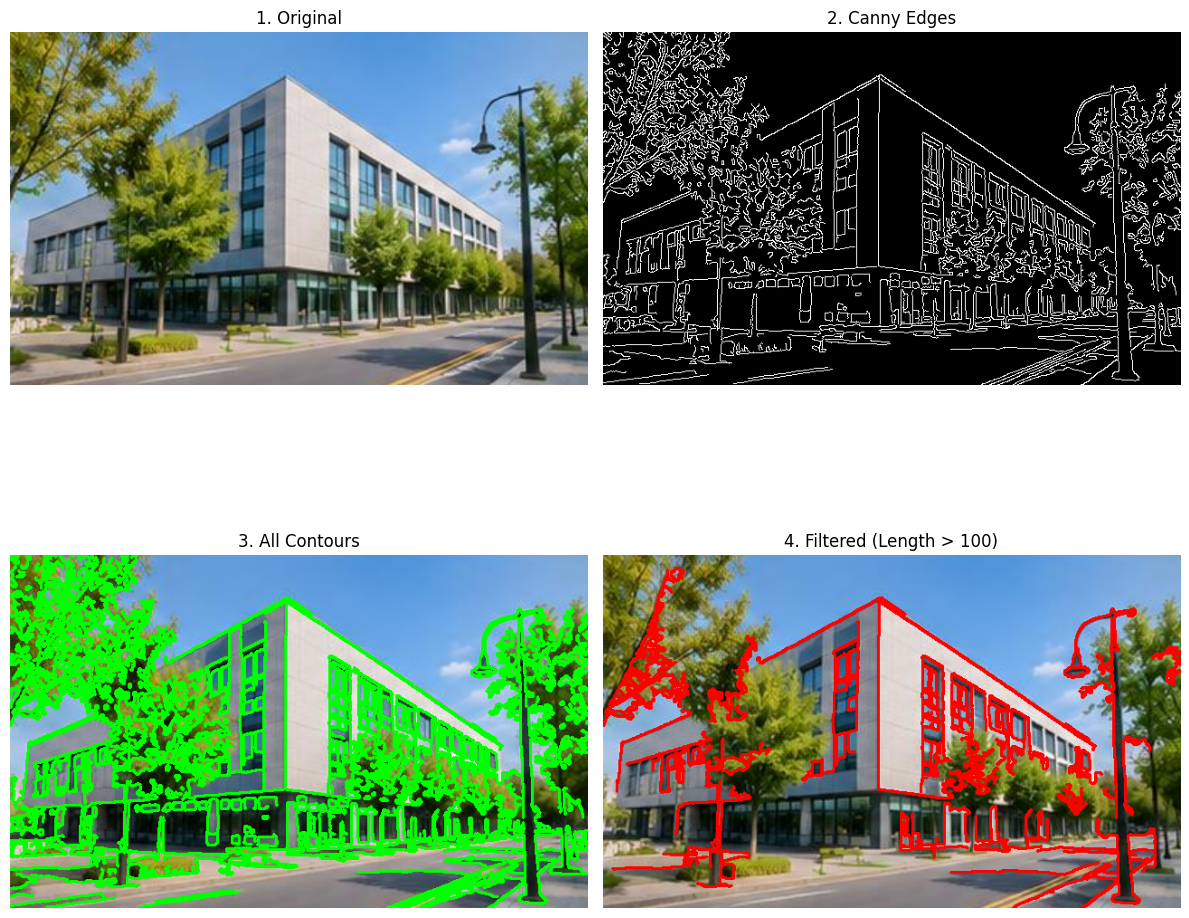

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 원본 이미지 읽기 및 그레이스케일 변환
img = cv2.imread("building.png")
  # matplotlib으로 출력하기 위해 BGR을 RGB로 변환
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Canny 에지 검출
edges = cv2.Canny(gray, 100, 200)

# 3. 윤곽선 검출
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 4. 모든 윤곽선 그리기 (비교용)
all_contours_img = img_rgb.copy()
cv2.drawContours(all_contours_img, contours, -1, (0, 255, 0), 2) # 초록색

# 5. 필터링 후 객체 표시 결과
result_img = img_rgb.copy()
for cnt in contours:
    # 얇은 에지 선의 특성을 고려하여 면적이 아닌 '길이'로 필터링
    length = cv2.arcLength(cnt, False)
    if length > 300:
        cv2.drawContours(result_img, [cnt], -1, (255, 0, 0), 2) # 빨간색

# 6. matplotlib을 이용한 2x2 격자 시각화
plt.figure(figsize=(12, 12))

# 첫 번째 칸: 원본
plt.subplot(2, 2, 1)
plt.title("1. Original")
plt.imshow(img_rgb)
plt.axis('off')

# 두 번째 칸: Canny 에지
plt.subplot(2, 2, 2)
plt.title("2. Canny Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

# 세 번째 칸: 모든 윤곽선
plt.subplot(2, 2, 3)
plt.title("3. All Contours")
plt.imshow(all_contours_img)
plt.axis('off')

# 네 번째 칸: 필터링 결과
plt.subplot(2, 2, 4)
plt.title("4. Filtered (Length > 100)")
plt.imshow(result_img)
plt.axis('off')

plt.tight_layout()
plt.show()

가우시안 블러를 이용한 노이즈 감소

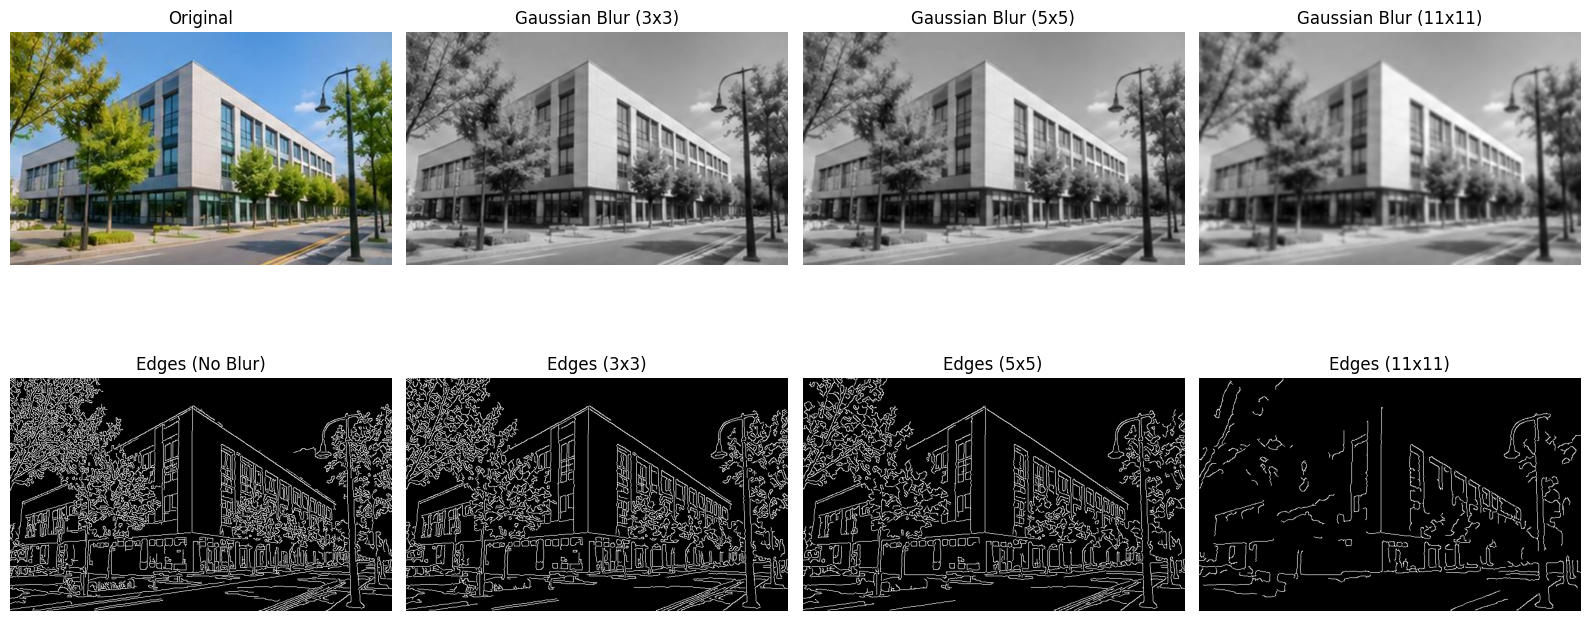

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("building.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 가우시안 블러 적용 (커널 크기 변경)
blur3 = cv2.GaussianBlur(gray, (3, 3), 0)
blur5 = cv2.GaussianBlur(gray, (5, 5), 0)
blur11 = cv2.GaussianBlur(gray, (11, 11), 0)

# Canny 에지 검출 (동일한 임계값 사용)
t1, t2 = 50, 150
edges_orig = cv2.Canny(gray, t1, t2) # 원본이미지 에지 검출
edges3 = cv2.Canny(blur3, t1, t2)
edges5 = cv2.Canny(blur5, t1, t2)
edges11 = cv2.Canny(blur11, t1, t2)

# Matplotlib을 이용한 2x4 형태의 시각화
plt.figure(figsize=(16, 8))

# [첫 번째 행] 원본 및 블러 이미지 리스트
images_row1 = [img_rgb, blur3, blur5, blur11]
titles_row1 = ['Original', 'Gaussian Blur (3x3)', 'Gaussian Blur (5x5)', 'Gaussian Blur (11x11)']

for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.title(titles_row1[i])
    # 원본(첫 번째)만 컬러로, 나머지는 흑백으로 출력
    if i == 0:
        plt.imshow(images_row1[i])
    else:
        plt.imshow(images_row1[i], cmap='gray')
    plt.axis('off')

# [두 번째 행] 에지 검출 결과 리스트
images_row2 = [edges_orig, edges3, edges5, edges11]
titles_row2 = ['Edges (No Blur)', 'Edges (3x3)', 'Edges (5x5)', 'Edges (11x11)']

for i in range(4):
    plt.subplot(2, 4, i + 5) # 2행은 5번째 칸부터 시작
    plt.title(titles_row2[i])
    plt.imshow(images_row2[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

임계값 변경에 따른 결과 비교 (건물 이미지)

- 낮은 임계값 → 에지가 많이 검출되지만 노이즈도 함께 검출됨

- 적절한 임계값 → 주요 윤곽선이 잘 검출되고 전체 구조가 명확함

- 높은 임계값 → 중요한 에지만 검출되어 결과가 단순하고 깔끔함

- 매우 높은 임계값 →강한 에지만 검출, 세부 에지가 많이 사라져서 단순 윤곽선만 남음

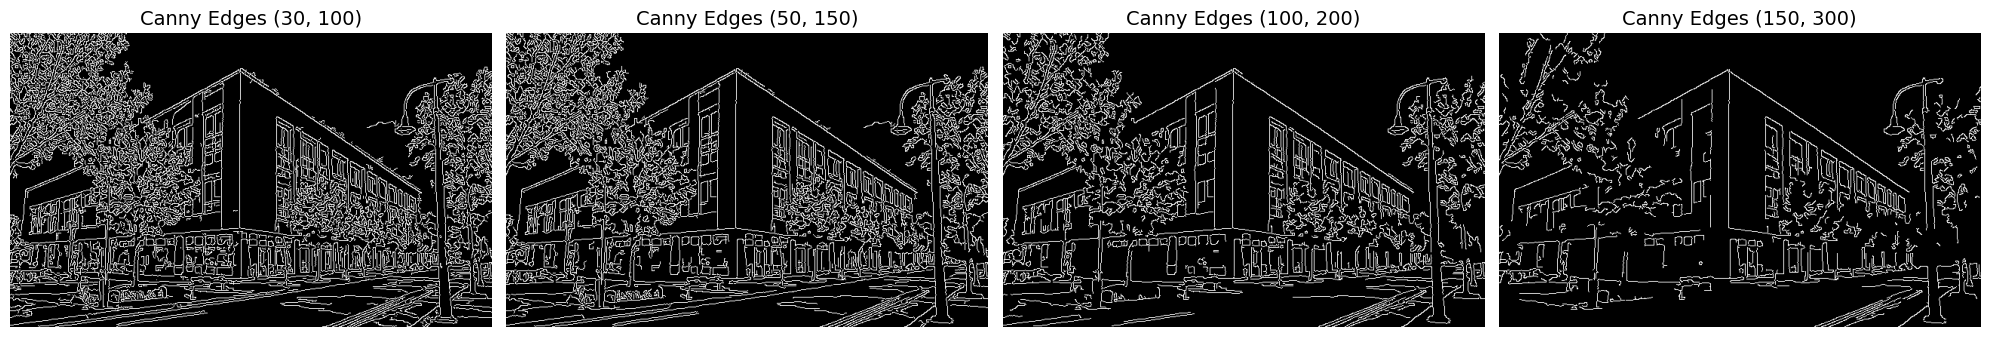

In [11]:
import cv2
import matplotlib.pyplot as plt

# 1. 원본 영상 그레이스케일로 읽기
gray = cv2.imread("building.png", cv2.IMREAD_GRAYSCALE)

# 2. 비교할 임계값 쌍 (t1, t2) 리스트 정의
thresholds = [(30, 100), (50, 150), (100, 200), (150, 300)]

# 3. 1x4 형태의 격자(서브플롯) 생성 (가로로 길게 설정)
plt.figure(figsize=(20, 5))

# 4. 반복문을 돌면서 4가지 임계값 각각 적용 및 시각화
for i, (t1, t2) in enumerate(thresholds):
    # Canny 에지 검출 수행
    edges = cv2.Canny(gray, t1, t2)

    # 서브플롯 위치 지정 (1행 4열 중 i+1번째)
    plt.subplot(1, 4, i + 1)

    # 제목에 사용된 임계값 명시
    plt.title(f"Canny Edges ({t1}, {t2})", fontsize=14)
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

# 5. 간격 자동 조절 및 출력
plt.tight_layout()
plt.show()
